# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`
# `Занятие 17. Трансформеры`
## `Занятие провел: Ким Роман (@karman_rim)`
## `Материалы составили: Алексеев Илья (@voorhs), Ким Роман (@karman_rim)`

### `Москва, Весенний семестр 2026`

Источники:

- **Attention**: [Ashish Vaswani et al., 2017](https://arxiv.org/abs/1706.03762), примерно 244 тысяч цитирований
- **FlashAttention**: [Tri Dao et al., 2022](https://arxiv.org/abs/2205.14135), примерно 5 тысяч цитирований

Сегодня мы разберём архитектуру **трансформера**, предложенную в работе [*Attention Is All You Need*](https://arxiv.org/abs/1706.03762) (Vaswani et al., 2017). На момент весны 2025 года у этой статьи более **230000+  цитирований** &ndash; это одна из самых влиятельных работ в истории машинного обучения, определившая облик практически всех современных языковых моделей.

---

## Какую задачу мы решаем?

В NLP существует широкий класс задач, где на вход подаётся одна последовательность, а на выход нужно получить другую. Такие задачи называют **sequence-to-sequence** (seq2seq):

- **Машинный перевод**: "The cat sat on the mat" $\to$ "Кот сидел на коврике"
- **Суммаризация текста**: длинный документ $\to$ краткое изложение
- **Диалоговые системы**: реплика пользователя $\to$ ответ модели

Ключевая трудность в том, что входная и выходная последовательности, как правило, имеют **разную длину** и **разную структуру** (например, разные языки с разным порядком слов). Поэтому нельзя просто применить одну и ту же сеть «поэлементно».

Естественная идея &ndash; разделить модель на две части:
1. **Кодировщик (encoder)**: читает входную последовательность целиком и сжимает её в набор векторных представлений.
2. **Декодировщик (decoder)**: опираясь на эти представления, порождает выходную последовательность токен за токеном.

Именно эта архитектура «кодировщик–декодировщик» лежит в основе seq2seq моделей. На прошлой лекции вы видели, как она реализуется с помощью RNN. Однако у RNN есть ряд существенных проблем:

- **Последовательные вычисления.** Скрытое состояние $h_t$ зависит от $h_{t-1}$, поэтому шаги нельзя считать параллельно. Это плохо ложится на архитектуру GPU, которые рассчитаны на массивный параллелизм.
- **Затухание и взрыв градиентов.** При обратном распространении через длинную цепочку рекуррентных шагов градиенты многократно умножаются на одни и те же матрицы весов, из-за чего они экспоненциально затухают или взрываются. LSTM и GRU смягчают эту проблему, но не устраняют полностью.
- **Бутылочное горлышко контекста.** В базовом encoder-decoder вся информация о входной последовательности сжимается в единственный вектор $h_T$. Для длинных предложений этот вектор не способен удержать всё содержание &ndash; информация о первых словах «забывается».

Механизм внимания (attention), добавленный поверх RNN, частично решает третью проблему: декодировщик получает прямой доступ ко всем скрытым состояниям кодировщика. Но первые две проблемы остаются. Возникает вопрос: а нельзя ли построить архитектуру **целиком** на механизме внимания, отказавшись от рекуррентности?

Именно так устроен **трансформер**. Сегодня мы пройдём путь от RNN-версии encoder-decoder до трансформера &ndash; архитектуры, которая заменяет рекуррентные связи механизмом внимания и за счёт этого обучается быстрее и качественнее.

## Вспоминаем RNN

На прошлой лекции вы узнали про принципы работы RNN:
- обучаемые преобразования для обработки последовательностей в рекуррентном режиме 
- shared parameters на каждом рекуррентном шаге
- контекстуализация векторных представлений слов
- механизм внимания в автокодировщике как дополнительный механизм памяти помимо рекуррентного вектора контекста

Мы вводили рекуррентную ячейку:

![rnn-cell](./figures/rnn-rnn-cell.drawio.svg)

Она имеет два входа $h,x$ и два выхода $h',y$:
$$
h'=g_h(W_1x+W_2h),\quad
y=g_y(W_3h'),
$$

Одним из применений была задача seq2seq моделирования с помощью автокодировщика:

![rnn-seq2seq](./figures/rnn-translation.drawio.svg)

Давайте запишем псевдокод алгоритма работы кодировщика и декодировщика.

### Алгоритм "RNN Encoder"

---

ВХОД:

- $E=[e(w_1), \ldots, e(w_T)]\in\mathbb{R}^{T\times d}$

ВЫХОД:

- $Y=[y_1,\ldots, y_T]\in\mathbb{R}^{T\times d}$
- $H=[h_1,\ldots, h_T]\in\mathbb{R}^{T\times d}$

---

1. $h_0 := 0$.
2. **Для** $ t $ от 1 до $ T $:
   - $ h_t, y_t := \text{RNNCell}(h_{t-1}, e(w_t)) $.

---



В алгоритме декодировщика используются так называемые **специальные токены** &ndash; выделенные элементы словаря, которые не соответствуют настоящим словам, а управляют поведением модели:

- **BOS** (Beginning Of Sequence) &ndash; токен начала последовательности. Подаётся на вход декодировщику как стартовый сигнал: «начинай генерировать».
- **EOS** (End Of Sequence) &ndash; токен конца последовательности. Когда декодировщик порождает этот токен, генерация останавливается.
- **PAD** (Padding) &ndash; токен-заполнитель. Используется для выравнивания последовательностей разной длины в одном батче до одинаковой длины.

### Алгоритм "RNN Decoder" (в режиме обучения)

---

ВХОД:

- $\tilde E=[e(\text{BOS}), e(\tilde w_1), \ldots, e(\tilde w_{n-1})]\in\mathbb{R}^{n\times d}$
- $h_T\in\mathbb{R}^d$

ВЫХОД:

- $Z=[z_0, z_1, \ldots, z_{n-1}]\in\mathbb{R}^{n\times d}$

---

1. $s_{-1} := h_T$.
2. $e(\tilde w_0):=e(\text{BOS})$
3. **Для** $ t $ от 0 до $ n -1$:
   - $ s_t, z_t := \text{RNNCell}(s_{t-1}, e(\tilde w_{t})) $.

---

### Механизм внимания

![](./figures/attention.drawio.svg)

$$
s_t=g_s(W_1z_t+W_2s_{t-1}+W_3c_t),\quad c_t=\sum_{i=1}^Th_i\alpha_{it},\\
\alpha_{it}={\exp(\text{sim}(s_{t-1},h_i))\over\sum_{j=1}^T\exp(\text{sim}(s_{t-1},h_j))},\quad\text{sim}(x,y)=\text{симметричная функция}.
$$


### Алгоритм "RNN Decoder с механизмом внимания"

**ВХОД:**  
- $\tilde E=[e(\text{BOS}), e(\tilde w_1), \ldots, e(\tilde w_{n-1})\in\mathbb{R}^{n\times d}$  
- $H=[h_1, h_2, \ldots, h_T]\in\mathbb{R}^{T\times d}$ 
- $Y=[y_1,\ldots,y_T]\in\mathbb{R}^{T\times d}$

**ВЫХОД:**  

- $Z=[z_0, z_1, \ldots, z_{n-1}]\in\mathbb{R}^{n\times d}$  

---

1. $s_{-1} := h_T$.
2. $e(\tilde w_0):=e(\text{BOS})$

3. **Для** $ t $ от 0 до $ n -1$:  

   - **Для** $ i $ от 1 до $ T $:  
   $$
   \alpha_{it} := \frac{\exp(\text{sim}(s_{t-1}, h_i))}{\sum_{j=1}^T \exp(\text{sim}(s_{t-1}, h_j))}
   $$
   - $c_t := \sum_{i=1}^T h_i \alpha_{it}$
   - $s_t, z_t := \text{RNNCell}(s_{t-1}, e(\tilde w_{t}), c_t).$

---

На этой лекции мы разовьем идею механизма внимания таким образом, что пройдем путь от RNN до трансформера &ndash; архитектуры, в которой все рекуррентные связи заменены механизмом внимания.


## Механизм внимания в векторной форме

Интуитивно механизм внимания решает задачу: «на какие части входной последовательности сейчас лучше всего смотреть, чтобы принять решение?». Для каждого шага мы берём текущий вектор-состояние (запрос), сравниваем его со всеми скрытыми представлениями (ключами), получаем веса важности и с их помощью усредняем значения.

Проанализируем эти формулы с точки зрения векторных операций. Алгоритм подсчёта атеншена для одного шага следующий:

---
ВХОД:
- $q\in\mathbb{R}^d$  [запрос, например $s_t$]
- $K\in\mathbb{R}^{T\times d}$ [ключи, например $h_1,\ldots,h_T$]
- $V\in\mathbb{R}^{T\times d}$ [значения, например $y_1,\ldots,y_T$]
---
ВЫХОД:
- $c\in\mathbb{R}^d$ [собранный контекст, например $c_t$]
---
1. $m := Kq$  
   Здесь мы считаем скалярные произведения запроса со всеми ключами. Чем больше значение компоненты $m_i$, тем «похожее» соответствующее скрытое состояние $h_i$ на текущий запрос.
2. $\alpha:=\text{Softmax}(m)$  
   Применяем Softmax и превращаем сырые «оценки похожести» в вероятностное распределение по позициям (веса важности, которые в сумме дают 1).
3. $c:=V^T\alpha$  
   Берём взвешенную сумму значений: каждое значение $v_i$ вносит вклад пропорционально своему весу $\alpha_i$. Полученный вектор $c$ &ndash; это «сжатое» представление всей последовательности с учётом текущего запроса.

---

Операцию, задаваемую этим алгоритмом, обозначим $\text{Attention}(q,K,V)$. Алгоритм декодировщика можно записать так:

---

1. $s_{-1} := h_T$.
2. $e(\tilde w_0):=e(\text{BOS})$
3. **Для** $ t $ от 0 до $ n -1$:  
    - $c_t := \text{Attention}(s_{t-1}, H, H)$
    - $s_t, z_t := \text{RNNCell}(s_{t-1}, e(\tilde w_{t}), c_t).$

---

Итак, на каждом шаге декодировщик сначала «собирает» из выходов кодировщика релевантный контекст $c_t$, а уже затем, опираясь на него и на предыдущее состояние, делает предсказание следующего токена. Обратимся к псевдокоду и схеме RNN с атеншеном. Мы видим, что в этом алгоритме есть два способа прокидывания связей между словами: рекуррентные формулы и атеншен пулинг. Идея механизма самовнимания в том, чтобы убрать рекуррентные связи и заменить их атеншен пулингом. Сделаем это аккуратно, распишем отдельно для кодировщика и для декодировщика.

### Самовнимание в кодировщике

Идея самовнимания (self-attention) в кодировщике состоит в том, что каждое слово «оглядывается» на всю входную последовательность и строит своё представление как взвешенную смесь других слов. Вместо того чтобы передавать информацию шаг за шагом, как в RNN, мы сразу позволяем каждому токену напрямую взаимодействовать со всеми остальными.

Попытаемся сначала придумать наивный алгоритм, как можно заменить рекуррентные связи на механизм внимания.

---

ВХОД:

- $E=[e(w_1), \ldots, e(w_T)]\in\mathbb{R}^{T\times d}$

ВЫХОД:

- $Y=[y_1,\ldots, y_T]\in\mathbb{R}^{T\times d}$
- $H=[h_1,\ldots, h_T]\in\mathbb{R}^{T\times d}$

---

1. **Для** $ t $ от 1 до $ T $:
    - $ c_t := \text{Attention}(e(w_t), E, E)$
    - $ y_t := \text{FC}(c_t) $.

---

В данном случае мы заменили $\text{RNNCell}$ на связку $\text{Attention}+\text{FC}$. То есть, для каждого слова мы сначала собираем контекст с помощью внимания, а затем прогоняем его через небольшой полносвязный блок, чтобы получить новое представление слова.

Мы успешно заменили рекуррентные связи в кодировщике. Принципиальное достоинство этого алгоритма в следующем: каждое слово в последовательности (кодировщика или декодировщика) имеет непосредственную связь со всеми другими словами в этой последовательности (а не как было в RNN: связь с непосредственными соседями). Т.е. последовательность "смотрит" на саму себя, отсюда название алгоритма.

Далее, ключевая идея в том, чтобы обнаружить пространство для оптимизации: заметьте, что все итерации цикла можно посчитать независимо. В функцию $\text{Attention}$ можно подать в качестве $q$ не один вектор $e(w_t)$, а сразу всю последовательность $E$. В алгоритме атеншена изменится лишь то, что вместо умножения $Kq\in\mathbb{R}^{T}$ будет умножение $QK^T\in\mathbb{R}^{T\times T}$.

Интерпретировать матрицу $QK^T$ удобно как «карту внимания»: элемент на позиции $(t, i)$ показывает, насколько токен на позиции $t$ обращает внимание на токен на позиции $i$.


---
ВХОД:
- $Q\in\mathbb{R}^{T\times d}$
- $K\in\mathbb{R}^{T\times d}$
- $V\in\mathbb{R}^{T\times d}$
---
ВЫХОД:
- $C\in\mathbb{R}^{T\times d}$

---

1. $m := QK^T/\sqrt{d}$  
   Масштабируемое скалярное произведение: считаем все «оценки похожести» между запросами и ключами сразу для всей последовательности.
2. $A:=\text{Softmax}(m)$  [построчно]  
   Преобразуем оценки в распределение внимания для каждой позиции.
3. $C:=A V$  
   Собираем новые представления токенов как взвешенные суммы значений.

---


Если записывать коротко:
$$
\text{Attention}(Q,K,V)=\text{Softmax}(QK^T)V.
$$
Полный алгоритм кодировщика тогда следующий:

---

ВХОД:

- $E=[e(w_1), \ldots, e(w_T)]\in\mathbb{R}^{T\times d}$

ВЫХОД:

- $Y=[y_1,\ldots, y_T]\in\mathbb{R}^{T\times d}$

---

1. $ C := \text{Attention}(E, E, E)$
2. $ Y := \text{FC}(C) $.

---


Таким образом кодировщик трансформера можно понимать как «слой, который переосмысляет каждое слово с учётом всех остальных слов в предложении». На схеме ниже это и изображено:

![](./figures/encoder-block-naive.drawio.svg)



### `Самовнимание в декодировщике`

В декодировщике идея похожа: каждое предсказанное слово смотрит на всю уже сгенерированную последовательность и на выходы кодировщика. Разница в том, что теперь мы должны соблюдать причинность: модель не имеет права «заглядывать в будущее», когда предсказывает следующий токен.

Как сделать все то же самое в декодировщике? Наивно, это можно сделать так:

---

**ВХОД:**  
- $ \tilde E=[e(\text{BOS}), e(\tilde w_1), \ldots, e(\tilde w_{n-1}) ]\in\mathbb{R}^{n\times d}$  
- $H=[h_1, h_2, \ldots, h_T]\in\mathbb{R}^{T\times d}$ 
- $Y=[y_1,\ldots,y_T]\in\mathbb{R}^{T\times d}$

**ВЫХОД:**  

- $Z=[z_0, z_1, \ldots, z_{n-1}]\in\mathbb{R}^{n\times d}$  

---

1. $e(\tilde w_0):=e(\text{BOS})$
1. **Для** $ t $ от 0 до $ n -1$: 
    - $s_t := \text{Attention}(e(\tilde w_t), \tilde E, \tilde E)$ [самовнимание]
    - $c_t := \text{Attention}(s_t, H, Y)$ [кросс-внимание]
    - $z_t := \text{FC}(c_t)$.

---

Здесь самовнимание позволяет каждому выходному токену учитывать уже сгенерированную часть предложения, а кросс-внимание &ndash; «подглядывать» в зашифрованное представление входного предложения (выходы кодировщика).

Первое, что мы можем улучшить, это добавить параллелизм, поскольку итерации цикла независимы:

---

**ВХОД:**  
- $ \tilde E=[e(\text{BOS}), e(\tilde w_1), \ldots, e(\tilde w_{n-1}) ]\in\mathbb{R}^{n\times d}$  
- $H=[h_1, h_2, \ldots, h_T]\in\mathbb{R}^{T\times d}$ 
- $Y=[y_1,\ldots,y_T]\in\mathbb{R}^{T\times d}$

**ВЫХОД:**  
- $ Z=[z_0, z_1, \ldots, z_{n-1} ]\in\mathbb{R}^{n\times d}$  

---

1. $S := \text{Attention}(\tilde E, \tilde E, \tilde E)$
2. $C := \text{Attention}(S, H, Y)$
3. $Z := \text{FC}(C)$.

---

Отлично! Вы помните, что помимо самовнимания в декодировщике ещё используется внимание, обращённое к выходам кодировщика. В контексте трансформеров это внимание называют кросс-вниманием, т.е. одна последовательность "смотрит" на другую.

![](figures/decoder-block-naive.drawio.svg)




<font color='Orange'>**Вопрос:**</font> в чём проблема этого алгоритма? Почему при обучении он будет показывать почти идеальное качество, но на практике окажется бесполезным? Подсказка: подумайте, какую информацию содержит активация $z_t$ и что по ней мы хотим предсказать.

#### Ответ:

Правда этот алгоритм ничему полезному не обучится. Надо вспомнить, что декодировщик учится на задачу Causal Language Modeling. В строке 1 самовнимание работает на всю последовательность и в обе стороны, прямо как в кодировщике. Это означает, что в активации $z_t$, по которой мы планируем делать предсказание токена $\tilde w_{t+1}$, уже будет содержаться информация о $e(\tilde w_{t+1})$. Происходит **утечка меток**: модель видит правильный ответ до того, как должна его предсказать. На обучении лосс будет стремиться к нулю, но модель просто научится «копировать» следующий токен из входа, а при генерации, когда будущих токенов ещё нет, она не сможет ничего предсказать.

Чтобы этого избежать, вводят маскированное внимание &ndash; модель может смотреть только на текущую и предыдущие позиции. Назовем следующий алгоритм операцией $\text{MaskedAttention}(Q,K,V)$.

---

ВХОД:
- $Q\in\mathbb{R}^{T\times d}$
- $K\in\mathbb{R}^{T\times d}$
- $V\in\mathbb{R}^{T\times d}$
---
ВЫХОД:
- $C\in\mathbb{R}^{T\times d}$

---

1. $m := QK^T/\sqrt{d}$
2. $m := \text{triu}(m, -\infty)$ [обнуляем (точнее, зануляем логиты до $-\infty$) в верхнем треугольнике матрицы, запрещая смотреть в будущее]
3. $A:=\text{Softmax}(m)$  [построчно]
4. $C:=A V$

---

Таким образом, маска обеспечивает причинность: при вычислении внимания для позиции $t$ модель учитывает только позиции $\le t$.

<font color='Orange'>**Вопрос:**</font> в текущем алгоритме внимания $\text{sim}(x,y)=\langle x,y\rangle$ &ndash; фиксированная функция без обучаемых параметров. Почему это делает модель недостаточно гибкой? Сколько обучаемых параметров у механизма внимания сейчас? Как можно это исправить, не усложняя сильно вычисления?

#### Ответ:

Текущая модель не содержит обучаемых операций, значит мы можем сделать модель более гибкой, добавив обучаемые параметры.

### Обучаемое внимание

До сих пор мы рассматривали внимание как «жёсткую» операцию, где похожесть между векторами измеряется просто скалярным произведением. Однако в реальных моделях важно, чтобы сама метрика похожести и способы извлечения информации из векторов были обучаемыми &ndash; тогда модель сможет подстраиваться под задачу.

В оригинальном атеншене для рекуррентных сетей были обучаемые параметры. Они были зашиты в функции $\text{sim}(x,y)=\text{FC}(x,y)$ &ndash; полносвязной сети, которая принимает на вход конкатенацию $x$ и $y$. Это делает операцию атеншен пулинга обучаемой, что добавляет гибкости и репрезентативной мощности архитектуре в целом. В введённом нами алгоритме используется $\text{sim}(x,y)=\langle x,y\rangle$. Как можно было бы ввести обучаемые параметры в неё, не усложняя сильно вычисления?

Простой и эффективный трюк: перед тем как считать внимание, мы пропускаем входные векторы через обучаемые линейные преобразования. Разные матрицы соответствуют трём ролям векторов &ndash; запросам (query), ключам (key) и значениям (value):
$$
\text{SelfAttention}(X)=\text{Attention}(XW_q,XW_k,XW_v),\\
\text{CrossAttention}(X,Y)=\text{Attention}(XW_q,YW_k,YW_v),
$$
где $W_q,W_k,W_v\in\mathbb{R}^{d\times d}$.

Интуитивно это значит, что модель учится: (1) понимать как устроено хорошее «пространство запросов», (2) кодировать «поисковый индекс» (ключи) и (3) хранить полезную информацию (значения). Всё остальное &ndash; стандартный механизм внимания, уже работающий в этих новых пространствах.


## Нормализация и skip-connection

Один только механизм внимания недостаточен для стабильного обучения глубоких моделей. На практике трансформеры почти всегда дополняют двумя строительными блоками: остаточными связями (skip-connections) и нормализацией (обычно LayerNorm). Они помогают градиенту хорошо протекать по сети и стабилизируют распределения активаций.

![](./figures/encoder-block.drawio.svg)

---
ВХОД:
- $X=[x_1,\ldots,x_T]\in\mathbb{R}^{T\times d}$
---
ВЫХОД:
- $Y=[y_1,\ldots,y_T]\in\mathbb{R}^{T\times d}$
---
1. $C:=\text{LayerNorm}(X+\text{SelfAttention}(X))$  
   Здесь $X$ складывается с результатом самовнимания (остаточная связь), а затем нормализуется по признаковому измерению.
4. $Y:=\text{LayerNorm}(C+\text{FC}(C))$  
   Аналогичный приём для полносвязного блока: добавляем вход к выходу и снова нормализуем.
---

Интуитивно skip-connection говорит модели: «если новый слой не нужен, можно просто пропустить изменение и оставить старое представление», а нормализация не даёт активациям «разбегаться» по масштабу. Вместе это делает обучение гораздо более устойчивым даже для десятков и сотен слоёв.

У декодировщика ситуация аналогичная, только между самовниманием и полносвязным блоком появляется ещё кросс-внимание.

![](./figures/decoder-block.drawio.svg)

---
ВХОД:
- $\tilde X=[\tilde x_1,\ldots,\tilde x_T]\in\mathbb{R}^{T\times d}$
- $Y=[y_1,\ldots,y_T]\in\mathbb{R}^{T\times d}$
---
ВЫХОД:
- $\tilde Y=[\tilde y_1,\ldots,\tilde y_T]\in\mathbb{R}^{T\times d}$
---
1. $S:=\text{LayerNorm}(\tilde X + \text{MaskedSelfAttention}(\tilde X))$
1. $S:=\text{LayerNorm}(S + \text{CrossAttention}(S, Y))$
5. $\tilde Y:=\text{LayerNorm}(S+\text{FC}(S))$
---

Такой «слой-трансформер» (attention + FFN + остаточные связи + нормализация) и является основным строительным элементом современных моделей.


## Вычислительная сложность трансформера

Трансформер часто представляют как «дорогую» модель, и это верно, если смотреть на асимптотику: внимание требует работы с матрицами размера $T\times T$, где $T$ &ndash; длина последовательности. Но при этом трансформеры прекрасно загружают GPU и выигрывают за счёт параллелизма.

Если взглянуть на псевдокод RNN и посчитать число операций и потребление памяти, то получится $O(T)$, где $T$ &ndash; длина последовательности. У трансформера в механизме внимания возникает перемножение матриц $QK^T$, поэтому сложность трансформера и потребление памяти $O(T^2)$.

Как так? Мы получили, что новая архитектура поедает колоссально много ресурсов, особенно в случае экстра длинных последовательностей. Однако может показаться парадоксом, но за одно и то же время трансформер способен пройти большее число шагов оптимизации, чем RNN. Дело в том, что в алгоритме RNN присутствует цикл по $t$, т.е. алгоритм принципиально последовательный, а такое медленно считается на GPU. В трансформере же всё сведено к матричному перемножению &ndash; эта операция эффективно параллелизуется на GPU и позволяет утилизировать больше вычислительной мощности. Т.е. трансформеру действительно нужно сделать больше операций с вещественными числами, но эти операции намного быстрее.

Это объясняется архитектурными особенностями GPU:

- SIMD: single instruction multiple data &ndash; одна инструкция применяется сразу к большому числу элементов.
- Иерархия памяти: важна локальность доступа к данным, чтобы реже «промахиваться» по кешу.
- High-throughput, а не low-latency: GPU лучше всего работает, когда мы даём ему много одинаковой работы сразу (как в матричных операциях), а не маленькие последовательные шаги.


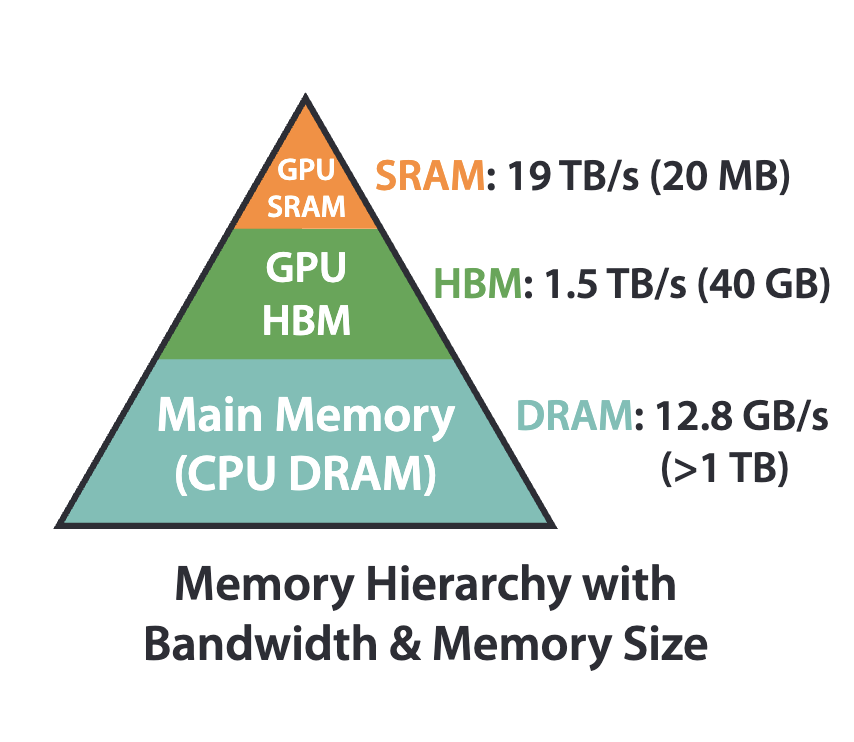

[Источник](https://arxiv.org/abs/2205.14135)

Однако существует много архитектурных приёмов ускорения трансформеров. Почти все они направлены на эффективное вычисление и хранение матриц внимания (пример: разреженное внимание, низкоранговые аппроксимации, кэширование ключей и значений в декодере и т.п.).

## Многоголовочность

Обычное (одноголовое) внимание уже даёт модели возможность гибко комбинировать информацию по последовательности. Но на практике оказалось полезным считать несколько разных «видов внимания» параллельно &ndash; это и есть многоголовочное внимание (multi-head attention).

Идея в том, что мы разбиваем исходное пространство признаков на несколько подпространств меньшей размерности и в каждом из них считаем своё внимание. Каждая голова может специализироваться на своём типе зависимостей: одна &ndash; на синтаксисе, другая &ndash; на длинных зависимостях, третья &ndash; на редких словах и т.д.

$$
\text{head}_i=\text{Attention}(Q\underbrace{W_q}_{d\times {d\over n}},K\underbrace{W_k}_{d\times {d\over n}},V\underbrace{W_v}_{d\times {d\over n}})\in\mathbb{R}^{T\times {d\over n}}, \quad i=\overline{1,n},\\
\text{MultiHeadAttention}(Q,K,V)=\text{concat}(\text{head}_1,\ldots,\text{head}_n)\underbrace{W_o}_{d\times d}
$$

Благодаря этому механизму возникает несколько эффектов:
- **Ансамблирование**: несколько «точек зрения» на одну и ту же последовательность, которые затем объединяются.
- **Узкое горлышко**: каждая голова работает в меньшем пространстве $d/n$, что ограничивает её ёмкость и заставляет головы специализироваться.
- **Ещё больше параллелизма**: все головы считаются независимо и одновременно, что хорошо ложится на архитектуру GPU.

В сумме многоголовочность делает слой внимания гораздо более выразительным при умеренном увеличении числа параметров.


## Полносвязный блок

Помимо внимания в каждом слое трансформера есть ещё один важный компонент &ndash; position-wise feed-forward сеть (полносвязный блок). Она применяется независимо к каждому токену (одни и те же веса для всех позиций) и отвечает за «нелинейную обработку» уже собранного контекста.

Блок position wise feed forward обладает одинаковой структурой почти во всех трансформерах: это двухслойная сеть, которая из активации размерности $d$ получает активацию размерности $4d$ и затем обратно $d$. 

![](./figures/ff.drawio.svg)

$$
\text{FC}(X):=g(X\underbrace{W_1}_{d\times {4d}}+b_1)\underbrace{W_2}_{4d\times d}+b_2.
$$

Смысл такой архитектуры двоякий:
- **Мягкий словарь.** Эти блоки составляют подавляющую часть всех параметров трансформера. Логично предположить, что в них хранится большая часть знаний трансформера как языковой модели о внешнем мире.
- **Утилизация GPU.** Такие сети называют широкими. Мы можем противопоставить ей глубокую сеть: что если взять полносвязную сеть с тем же числом параметров, но сделать много узких слоёв вместо двух широких? Эта архитектура плоха по той же причине, почему плох RNN: лучше использовать одну большую, но параллелизуемую операцию, чем много маленьких, но последовательных.

В оригинальном трансформере и в целом в трансформерах долгое время использовались функции активации наподобие ReLU и GELU. Сейчас всё чаще используются SwiGLU (особенно в LLM):

1. $h_1:=XW_1+b_1$ [расширение $d\to 4d$]
2. $h_2:=XW_2+b_2$ [расширение $d\to 4d$]
3. $h_\text{SwiGLU}:=h_1\circ\sigma(h_1)\circ h_2$ [размерность $4d$]
4. $\text{FC}(X):=h_\text{SwiGLU}W_3+b_3$ [сужение $4d\to d$]

Интуитивно SwiGLU даёт более гибкую и плавную нелинейность, чем ReLU, и лучше подходит для очень больших языковых моделей, улучшая качество при сопоставимых затратах.


## Позиционная кодировка

Заметим одну примечательную особенность: атеншен обрабатывает множество, а не последовательность. В рекуррентных сетях порядок слов учитывался в самом алгоритме за счёт использования цикла по $t$. Сейчас же мы имеем только перемножение матриц, порядок слов отражается только в порядке строк в этих матрицах, но не в самих признаках. В текущем виде информация о порядке слов нигде не учитывается.

Чтобы модель понимала, где в предложении находится каждое слово, вводят **позиционную кодировку**. Идея в том, чтобы ко входным эмбедингам слов добавлять специальный эмбединг, соответствующий номеру слова в предложении. Тогда даже два одинаковых слова, стоящих в разных местах, будут иметь разные суммарные векторы «эмбединг + позиция».

Оригинальный трансформер использовал фиксированные эмбединги, получаемые с помощью синусов и косинусов. Затем сообщество открыло, что эти эмбединги можно просто инициализировать случайными и обучать. Сейчас продвинутые трансформеры вообще отошли от этой идеи и используют методы, которые напрямую влияют на механизм подсчёта атеншена (rotary embeddings, ALiBi и др.).

Синусоидная кодировка состоит в том, чтобы завести матрицу $P\in\mathbb{R}^{T\times d}$, где $T$ &ndash; максимальная длина последовательностей, которые наша модель будет поддерживать. Матрица определяется следующими правилами:
$$
P_{m,2i}:=\sin\left({m\over10000^{2i/d}}\right),\quad
P_{m,2i+1}:=\cos\left({m\over10000^{2i/d}}\right),
$$
для всех $i=\overline{1,d/2}$.

Такая форма выбрана так, чтобы близкие по позиции токены имели близкие кодировки, а модель могла обобщать на длины последовательностей, которых не видела при обучении.


## Полная схема трансформера

На этой схеме собраны вместе все элементы, которые мы обсудили: самовнимание, кросс-внимание, многоголовочность, позиционные кодировки, полносвязные блоки, нормализация и остаточные связи. Кодировщик последовательно применяет несколько одинаковых слоёв к входной последовательности, а декодировщик &ndash; к выходной, дополнительно заглядывая в представления кодировщика через кросс-внимание.

Важно понимать, что трансформер &ndash; это не «магическая чёрная коробка», а композиция простых по отдельности блоков. Схема лишь показывает, как именно эти блоки соединены между собой.

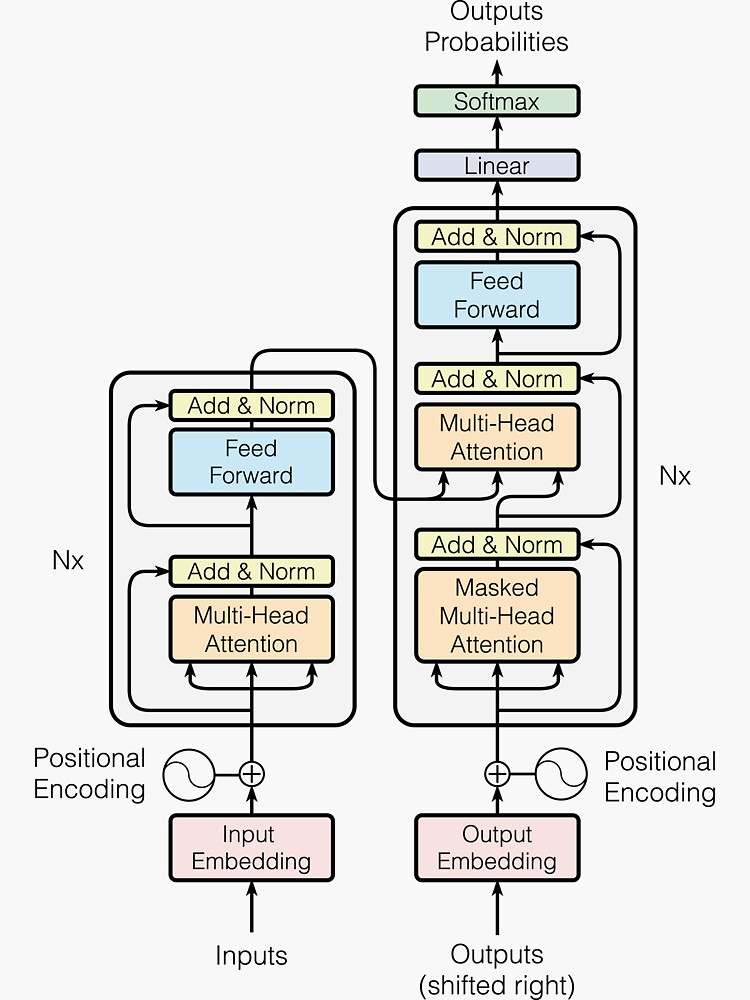

[Источник](https://arxiv.org/abs/1706.03762)